# Redes Neuronales — Regresión de Salarios

[![francomansilla.com](https://img.shields.io/badge/francomansilla.com-555555?style=flat&logo=globe&logoColor=white)](https://www.francomansilla.com)

Este notebook entrena y compara distintas arquitecturas de redes neuronales (MLP) para predecir salarios a partir de variables socioeconómicas. Se escalan los datos con `StandardScaler`, se exploran activaciones y tamaños de capa progresivamente, y se optimizan los hiperparámetros con `GridSearchCV`. Al final se entrena el modelo ganador con todos los datos y se generan predicciones en casos nuevos.

<br>

**Librerías**

[![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat&logo=pandas&logoColor=white)](https://pandas.pydata.org/docs/)
[![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat&logo=numpy&logoColor=white)](https://numpy.org/doc/)
[![Matplotlib](https://img.shields.io/badge/Matplotlib-11557c?style=flat&logo=python&logoColor=white)](https://matplotlib.org/stable/index.html)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=flat&logo=scikit-learn&logoColor=white)](https://scikit-learn.org/stable/)

**Modelos y métodos**

[![MLPRegressor](https://img.shields.io/badge/MLPRegressor-0078D4?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)
[![Pipeline](https://img.shields.io/badge/Pipeline-6A0DAD?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
[![GridSearchCV](https://img.shields.io/badge/GridSearchCV-E34F26?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
[![StandardScaler](https://img.shields.io/badge/StandardScaler-2E8B57?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

**Métricas**

[![MAPE](https://img.shields.io/badge/MAPE-DC143C?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html)
[![RMSE](https://img.shields.io/badge/RMSE-B8860B?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
[![R²](https://img.shields.io/badge/R²-228B22?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

---


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline


In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/fmansillaib/umayor_class/main/datasets/datos_transversales_paneles/determinantes_salario/datos.csv')
df

,salario,educ,exper,perm,marr,#dep,nort,sur,oeste
0,"21,63",18,8,8,0,0,0,0,0
1,"4,5",12,37,14,1,0,0,0,1
2,"3,5",12,31,3,0,1,0,0,1
3,"2,9",6,49,7,1,0,0,1,0
4,"2,54",9,2,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...
521,"5,11",11,3,0,0,0,0,0,1
522,"7,25",12,14,5,1,3,0,0,1
523,"2,92",3,11,30,0,0,0,1,0
524,"6,33",12,23,8,1,2,0,1,0


In [4]:
from sklearn.model_selection import train_test_split

df_entrenamiento, df_validacion = train_test_split(df, test_size=0.30, random_state=42)
df_entrenamiento = df_entrenamiento.reset_index(drop=True)
df_validacion    = df_validacion.reset_index(drop=True)

print(f"Entrenamiento: {len(df_entrenamiento)} filas")
print(f"Validación:    {len(df_validacion)} filas")


Entrenamiento: 368 filas
Validación:    158 filas


## Red Neuronal (MLP)

Una red neuronal recibe variables de entrada, las procesa en capas de neuronas y entrega una predicción. Se escalan los datos antes de entrenar porque las redes son sensibles a diferencias de magnitud entre variables.

In [5]:
warnings.filterwarnings('ignore', category=ConvergenceWarning)

target = 'salario'
features = [c for c in df.columns if c != target]

X_train = df_entrenamiento[features]
y_train = df_entrenamiento[target]
X_val   = df_validacion[features]
y_val   = df_validacion[target]

# Convierte comas decimales (ej. '3,4') a float para evitar errores en sklearn
y_train = pd.to_numeric(y_train.astype(str).str.replace(',', '.', regex=False), errors='coerce')
y_val   = pd.to_numeric(y_val.astype(str).str.replace(',', '.', regex=False), errors='coerce')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)


### Una sola neurona lineal

In [10]:
modelo1 = MLPRegressor(hidden_layer_sizes=(1,), activation='identity', max_iter=500, random_state=42)
modelo1.fit(X_train_sc, y_train)
y_pred1 = modelo1.predict(X_val_sc)
print(f"MAPE: {mean_absolute_percentage_error(y_val, y_pred1)*100:.2f}%")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred1)):.4f}")
print(f"R²  : {r2_score(y_val, y_pred1):.4f}")


MAPE: 69.64%
RMSE: 5.0604
R²  : -0.9025


### Dos neuronas lineales

In [7]:
modelo3 = MLPRegressor(hidden_layer_sizes=(2,), activation='identity', max_iter=500, random_state=42)
modelo3.fit(X_train_sc, y_train)
y_pred3 = modelo3.predict(X_val_sc)
print(f"MAPE: {mean_absolute_percentage_error(y_val, y_pred3)*100:.2f}%")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred3)):.4f}")
print(f"R²  : {r2_score(y_val, y_pred3):.4f}")


MAPE: 37.02%
RMSE: 3.4583
R²  : 0.1114


### Dos neuronas — cambiando la función de activación

In [8]:
for activacion in ['identity', 'relu', 'tanh', 'logistic']:
    m = MLPRegressor(hidden_layer_sizes=(2,), activation=activacion, max_iter=500, random_state=42)
    m.fit(X_train_sc, y_train)
    y_p = m.predict(X_val_sc)
    print(f"{activacion:10s} → MAPE: {mean_absolute_percentage_error(y_val, y_p)*100:.2f}%  RMSE: {np.sqrt(mean_squared_error(y_val, y_p)):.4f}  R²: {r2_score(y_val, y_p):.4f}")


identity   → MAPE: 37.02%  RMSE: 3.4583  R²: 0.1114
relu       → MAPE: 59.42%  RMSE: 5.2945  R²: -1.0826
tanh       → MAPE: 47.25%  RMSE: 4.7507  R²: -0.6768
logistic   → MAPE: 54.93%  RMSE: 5.2340  R²: -1.0352


### Una capa oculta con 2 neuronas — cambiando la función de activación

In [9]:
for activacion in ['identity', 'relu', 'tanh', 'logistic']:
    m = MLPRegressor(hidden_layer_sizes=(2, 2), activation=activacion, max_iter=500, random_state=42)
    m.fit(X_train_sc, y_train)
    y_p = m.predict(X_val_sc)
    print(f"{activacion:10s} → MAPE: {mean_absolute_percentage_error(y_val, y_p)*100:.2f}%  RMSE: {np.sqrt(mean_squared_error(y_val, y_p)):.4f}  R²: {r2_score(y_val, y_p):.4f}")


identity   → MAPE: 41.91%  RMSE: 2.9538  R²: 0.3518
relu       → MAPE: 97.45%  RMSE: 6.9425  R²: -2.5808
tanh       → MAPE: 43.29%  RMSE: 4.8889  R²: -0.7757
logistic   → MAPE: 46.24%  RMSE: 4.9855  R²: -0.8465


### Multilayer Perceptron — pocas capas y pocas neuronas

In [12]:
arquitecturas = {
    "1 capa  (4)":       (4,),
    "2 capas (4, 4)":    (4, 4),
    "3 capas (4, 4, 4)": (4, 4, 4),
}

for nombre, capas in arquitecturas.items():
    m = MLPRegressor(hidden_layer_sizes=capas, activation='identity', max_iter=500, random_state=42)
    m.fit(X_train_sc, y_train)
    y_p = m.predict(X_val_sc)
    print(f"{nombre:22s} → MAPE: {mean_absolute_percentage_error(y_val, y_p)*100:.2f}%  RMSE: {np.sqrt(mean_squared_error(y_val, y_p)):.4f}  R²: {r2_score(y_val, y_p):.4f}")


1 capa  (4)            → MAPE: 36.99%  RMSE: 3.0983  R²: 0.2868
2 capas (4, 4)         → MAPE: 41.88%  RMSE: 2.9536  R²: 0.3519
3 capas (4, 4, 4)      → MAPE: 42.24%  RMSE: 2.9564  R²: 0.3507


### Tabla comparativa de todos los modelos

In [ ]:
modelos_config = [
    ("1 neurona lineal",          (1,),       'identity'),
    ("2 neuronas lineales",        (2,),       'identity'),
    ("3 neuronas lineales",        (3,),       'identity'),
    ("2 neuronas — relu",          (2,),       'relu'),
    ("2 neuronas — tanh",          (2,),       'tanh'),
    ("2 neuronas — logistic",      (2,),       'logistic'),
    ("2 capas (2,2) — identity",   (2, 2),     'identity'),
    ("2 capas (2,2) — relu",       (2, 2),     'relu'),
    ("2 capas (2,2) — tanh",       (2, 2),     'tanh'),
    ("2 capas (2,2) — logistic",   (2, 2),     'logistic'),
    ("MLP 1 capa (4) — relu",      (4,),       'relu'),
    ("MLP 2 capas (4,4) — relu",   (4, 4),     'relu'),
    ("MLP 3 capas (4,4,4) — relu", (4, 4, 4), 'relu'),
    ("MLP 1 capa (4) — identity",      (4,),       'identity'),
    ("MLP 2 capas (4,4) — identity",   (4, 4),     'identity'),
    ("MLP 3 capas (4,4,4) — identity", (4, 4, 4), 'identity'),
]

resultados = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for nombre, capas, act in modelos_config:
        m = MLPRegressor(hidden_layer_sizes=capas, activation=act, max_iter=500, random_state=42)
        m.fit(X_train_sc, y_train)
        mape_train = mean_absolute_percentage_error(y_train, m.predict(X_train_sc)) * 100
        mape_val   = mean_absolute_percentage_error(y_val,   m.predict(X_val_sc))   * 100
        rmse_train = np.sqrt(mean_squared_error(y_train, m.predict(X_train_sc)))
        rmse_val   = np.sqrt(mean_squared_error(y_val,   m.predict(X_val_sc)))
        r2_train   = r2_score(y_train, m.predict(X_train_sc))
        r2_val     = r2_score(y_val,   m.predict(X_val_sc))
        resultados.append([nombre, f"{mape_train:.2f}%", f"{mape_val:.2f}%",
                           f"{rmse_train:.4f}", f"{rmse_val:.4f}",
                           f"{r2_train:.4f}", f"{r2_val:.4f}"])

df_tabla = pd.DataFrame(resultados, columns=["Modelo", "MAPE Train", "MAPE Val", "RMSE Train", "RMSE Val", "R² Train", "R² Val"])
df_tabla


,Modelo,MAPE Train,MAPE Val,RMSE Train,RMSE Val,R² Train,R² Val
0,1 neurona lineal,73.94%,69.64%,4.9232,5.0604,-0.9987,-0.9025
1,2 neuronas lineales,40.25%,37.02%,3.3340,3.4583,0.0834,0.1114
2,3 neuronas lineales,38.60%,39.13%,2.8728,2.9539,0.3195,0.3517
3,2 neuronas — relu,53.35%,59.42%,4.8860,5.2945,-0.9686,-1.0826
4,2 neuronas — tanh,43.67%,47.25%,4.4166,4.7507,-0.6085,-0.6768
5,2 neuronas — logistic,55.70%,54.93%,4.9584,5.2340,-1.0274,-1.0352
6,"2 capas (2,2) — identity",41.11%,41.91%,2.8526,2.9538,0.3290,0.3518
7,"2 capas (2,2) — relu",97.33%,97.45%,6.6732,6.9425,-2.6722,-2.5808
8,"2 capas (2,2) — tanh",42.44%,43.29%,4.6098,4.8889,-0.7523,-0.7757
9,"2 capas (2,2) — logistic",45.70%,46.24%,4.7105,4.9855,-0.8297,-0.8465


### GridSearch — mejor modelo

In [23]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=1000, random_state=42))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(4,), (8,), (4, 4), (8, 8)],
    'mlp__activation':         ['relu', 'tanh', 'identity'],
    'mlp__alpha':              [0.001, 0.01, 0.1],
    'mlp__learning_rate_init': [0.0001, 0.001, 0.01, 0.1],
    'mlp__solver':             ['adam', 'sgd', 'lbfgs']
}

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    gs = GridSearchCV(pipeline, param_grid, scoring='neg_mean_absolute_percentage_error', cv=5, n_jobs=1)
    gs.fit(X_train, y_train)

print("Mejores parámetros:")
for k, v in gs.best_params_.items():
    print(f"  {k}: {v}")

mejor = gs.best_estimator_
mape_train = mean_absolute_percentage_error(y_train, mejor.predict(X_train)) * 100
mape_val   = mean_absolute_percentage_error(y_val,   mejor.predict(X_val))   * 100
rmse_train = np.sqrt(mean_squared_error(y_train, mejor.predict(X_train)))
rmse_val   = np.sqrt(mean_squared_error(y_val,   mejor.predict(X_val)))
r2_train   = r2_score(y_train, mejor.predict(X_train))
r2_val     = r2_score(y_val,   mejor.predict(X_val))

print(f"\nMAPE Train : {mape_train:.2f}%")
print(f"MAPE Val   : {mape_val:.2f}%")
print(f"RMSE Train : {rmse_train:.4f}")
print(f"RMSE Val   : {rmse_val:.4f}")
print(f"R² Train   : {r2_train:.4f}")
print(f"R² Val     : {r2_val:.4f}")


Mejores parámetros:
  mlp__activation: tanh
  mlp__alpha: 0.1
  mlp__hidden_layer_sizes: (4,)
  mlp__learning_rate_init: 0.001
  mlp__solver: adam

MAPE Train : 38.08%
MAPE Val   : 41.79%
RMSE Train : 3.0700
RMSE Val   : 3.3590
R² Train   : 0.2228
R² Val     : 0.1617


### Diagnóstico del mejor modelo — predicho vs real y distribución del error

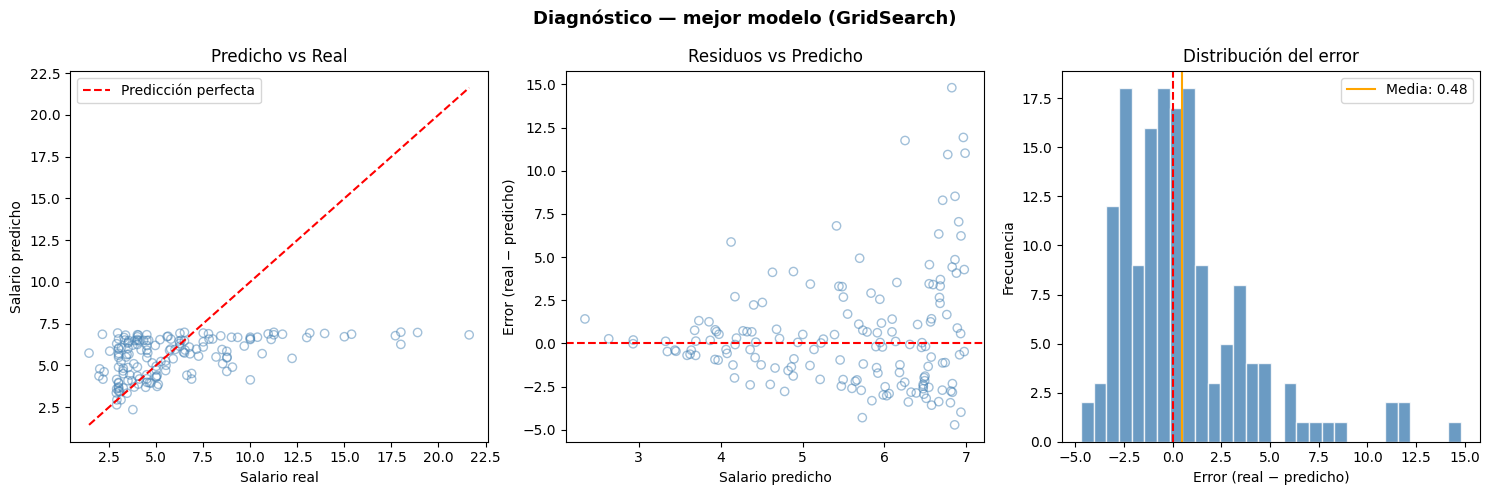

In [24]:
y_pred_val = mejor.predict(X_val)
errores    = y_val - y_pred_val

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- 1. Predicho vs Real ---
ax = axes[0]
lims = [min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())]
ax.scatter(y_val, y_pred_val, alpha=0.5, edgecolors='steelblue', facecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Salario real')
ax.set_ylabel('Salario predicho')
ax.set_title('Predicho vs Real')
ax.legend()

# --- 2. Residuos vs Predicho ---
ax = axes[1]
ax.scatter(y_pred_val, errores, alpha=0.5, edgecolors='steelblue', facecolors='none')
ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
ax.set_xlabel('Salario predicho')
ax.set_ylabel('Error (real − predicho)')
ax.set_title('Residuos vs Predicho')

# --- 3. Distribución del error ---
ax = axes[2]
ax.hist(errores, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='r', linestyle='--', linewidth=1.5)
ax.axvline(errores.mean(), color='orange', linestyle='-', linewidth=1.5, label=f'Media: {errores.mean():.2f}')
ax.set_xlabel('Error (real − predicho)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del error')
ax.legend()

plt.suptitle('Diagnóstico — mejor modelo (GridSearch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Modelo final — entrenado con todos los datos

In [25]:
X_todo = df[features]
y_todo = df[target]

# Asegura que el target esté en formato numérico (convierte '21,63' -> 21.63)
y_todo = pd.to_numeric(y_todo.astype(str).str.replace(',', '.', regex=False), errors='coerce')

mejor_params = gs.best_params_
modelo_final = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=mejor_params['mlp__hidden_layer_sizes'],
        activation=mejor_params['mlp__activation'],
        alpha=mejor_params['mlp__alpha'],
        max_iter=1000,
        random_state=42
    ))
])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    modelo_final.fit(X_todo, y_todo)

y_pred_todo = modelo_final.predict(X_todo)
errores_todo = y_todo - y_pred_todo

mape_todo = mean_absolute_percentage_error(y_todo, y_pred_todo) * 100
rmse_todo = np.sqrt(mean_squared_error(y_todo, y_pred_todo))
r2_todo   = r2_score(y_todo, y_pred_todo)

print(f"MAPE (todos los datos) : {mape_todo:.2f}%")
print(f"RMSE (todos los datos) : {rmse_todo:.4f}")
print(f"R²   (todos los datos) : {r2_todo:.4f}")
print(f"N                      : {len(y_todo)}")


MAPE (todos los datos) : 37.42%
RMSE (todos los datos) : 2.9127
R²   (todos los datos) : 0.3232
N                      : 526


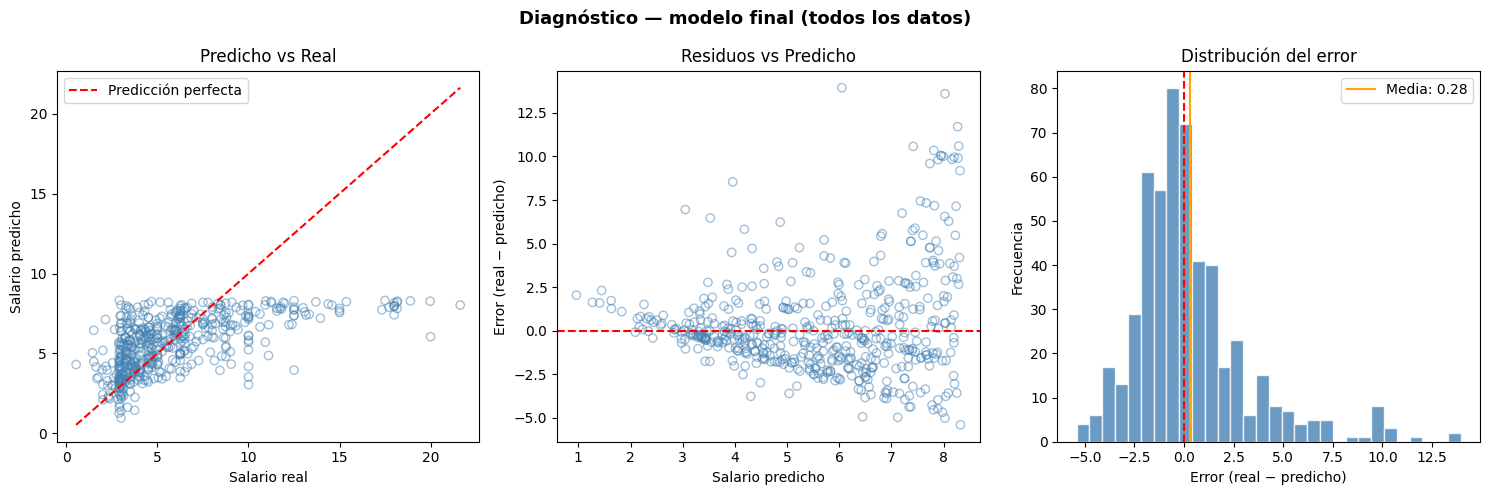

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- 1. Predicho vs Real ---
ax = axes[0]
lims = [min(y_todo.min(), y_pred_todo.min()), max(y_todo.max(), y_pred_todo.max())]
ax.scatter(y_todo, y_pred_todo, alpha=0.5, edgecolors='steelblue', facecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Salario real')
ax.set_ylabel('Salario predicho')
ax.set_title('Predicho vs Real')
ax.legend()

# --- 2. Residuos vs Predicho ---
ax = axes[1]
ax.scatter(y_pred_todo, errores_todo, alpha=0.5, edgecolors='steelblue', facecolors='none')
ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
ax.set_xlabel('Salario predicho')
ax.set_ylabel('Error (real − predicho)')
ax.set_title('Residuos vs Predicho')

# --- 3. Distribución del error ---
ax = axes[2]
ax.hist(errores_todo, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='r', linestyle='--', linewidth=1.5)
ax.axvline(errores_todo.mean(), color='orange', linestyle='-', linewidth=1.5, label=f'Media: {errores_todo.mean():.2f}')
ax.set_xlabel('Error (real − predicho)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del error')
ax.legend()

plt.suptitle('Diagnóstico — modelo final (todos los datos)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Predicción en casos nuevos

In [28]:
# Columnas: educ, exper, perm, marr, #dep, nort, sur, oeste
casos_nuevos = pd.DataFrame([
    {"educ": 18, "exper":  2, "perm":  0, "marr": 0, "#dep": 0, "nort": 0, "sur": 0, "oeste": 0},  # Recién egresado universitario
    {"educ": 12, "exper": 20, "perm": 10, "marr": 1, "#dep": 2, "nort": 0, "sur": 0, "oeste": 1},  # Técnico con experiencia, casado
    {"educ":  6, "exper": 35, "perm": 25, "marr": 1, "#dep": 3, "nort": 0, "sur": 1, "oeste": 0},  # Poca educación, mucha experiencia
    {"educ": 16, "exper": 10, "perm":  5, "marr": 0, "#dep": 1, "nort": 1, "sur": 0, "oeste": 0},  # Universitario con algo de experiencia
    {"educ": 12, "exper":  5, "perm":  2, "marr": 0, "#dep": 0, "nort": 0, "sur": 0, "oeste": 0},  # Secundario, poca experiencia
])

predicciones = modelo_final.predict(casos_nuevos)

casos_nuevos['salario_estimado'] = predicciones.round(2)
casos_nuevos.index = [f"Caso {i+1}" for i in range(len(casos_nuevos))]
casos_nuevos

,educ,exper,perm,marr,#dep,nort,sur,oeste,salario_estimado
Caso 1,18,2,0,0,0,0,0,0,6.61
Caso 2,12,20,10,1,2,0,0,1,7.65
Caso 3,6,35,25,1,3,0,1,0,5.76
Caso 4,16,10,5,0,1,1,0,0,7.23
Caso 5,12,5,2,0,0,0,0,0,4.16
